# 05 - Feature Engineering (Partie ML)

**Objectif** : Transformer les données brutes nettoyées en features exploitables par le modèle ML.

**Étapes** :
1. Chargement et vérification du dataset nettoyé
2. Correction des anomalies résiduelles
3. Traitement du texte (title + keywords + overview) → TF-IDF
4. Encodage des variables catégorielles (genres, adult, language)
5. Standardisation des variables numériques (budget, runtime)
6. Extraction des variables temporelles (release_year, release_month)
7. Assemblage final de la matrice X et du vecteur y
8. Sauvegarde

**Principe clé** : Aucune variable post-sortie, aucune variable dérivée de la rentabilité dans X.

## 1. Chargement et vérification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Chargement du dataset nettoyé
df = pd.read_csv('../data/processed/movies_cleaned2.csv')

print(f"Shape : {df.shape}")
print(f"\nColonnes : {df.columns.tolist()}")
print(f"\nTypes :")
print(df.dtypes)
print(f"\nValeurs manquantes :")
print(df.isnull().sum())
print(f"\nDistribution de la cible (rentabilite) :")
print(df['rentabilite'].value_counts().sort_index())

Shape : (16354, 12)

Colonnes : ['title', 'keywords', 'overview', 'genres', 'adult', 'budget', 'runtime', 'original_language', 'production_countries', 'production_companies', 'rentabilite', 'release_year']

Types :
title                       str
keywords                    str
overview                    str
genres                      str
adult                      bool
budget                    int64
runtime                   int64
original_language           str
production_countries        str
production_companies        str
rentabilite               int64
release_year            float64
dtype: object

Valeurs manquantes :
title                      0
keywords                5241
overview                2215
genres                     0
adult                      0
budget                     0
runtime                    0
original_language          0
production_countries       0
production_companies       0
rentabilite                0
release_year               0
dtype: int64

Dis

## 2. Corrections des anomalies résiduelles

In [2]:
# --- 2.1 Filtrage des années aberrantes ---
# On a détecté release_year max = 2085, ce qui est incohérent
print(f"Avant filtrage année : {len(df)} films")
print(f"Années min/max : {df['release_year'].min()} / {df['release_year'].max()}")

# Garder uniquement les films avec une année réaliste (jusqu'à 2025)
df = df[df['release_year'] <= 2025].copy()
print(f"Après filtrage année <= 2025 : {len(df)} films")
print(f"Années min/max : {df['release_year'].min()} / {df['release_year'].max()}")

Avant filtrage année : 16354 films
Années min/max : 1898.0 / 2085.0
Après filtrage année <= 2025 : 16312 films
Années min/max : 1898.0 / 2025.0


In [3]:
# --- 2.2 Remplir les NaN du texte par des chaînes vides ---
# keywords : 5241 NaN, overview : 2215 NaN
for col in ['title', 'keywords', 'overview']:
    df[col] = df[col].fillna('')

print("Valeurs manquantes après correction :")
print(df.isnull().sum())

Valeurs manquantes après correction :
title                   0
keywords                0
overview                0
genres                  0
adult                   0
budget                  0
runtime                 0
original_language       0
production_countries    0
production_companies    0
rentabilite             0
release_year            0
dtype: int64


## 3. Traitement du texte → TF-IDF

On combine `title`, `keywords` et `overview` en un seul champ texte, puis on applique TF-IDF.

**Justification ML** : Le texte (mots-clés, synopsis) peut porter un signal sur la rentabilité (ex: certains thèmes/mots sont associés à des films plus rentables).

In [4]:
import re
import string

# --- 3.1 Fonction de nettoyage du texte ---
def clean_text(text):
    """Nettoyage du texte : minuscules, suppression ponctuation et chiffres."""
    if not isinstance(text, str):
        return ''
    text = text.lower()                          # Minuscules
    text = re.sub(r'[^a-zA-Z\s]', '', text)      # Garder que les lettres
    text = re.sub(r'\s+', ' ', text).strip()      # Nettoyer les espaces multiples
    return text

# --- 3.2 Combiner les colonnes texte ---
df['text_combined'] = (df['title'] + ' ' + df['keywords'] + ' ' + df['overview']).apply(clean_text)

# Vérification
print("Exemples de texte combiné :")
print(df['text_combined'].head(3).tolist())
print(f"\nTextes vides : {(df['text_combined'] == '').sum()}")

Exemples de texte combiné :
['inception rescue mission dream airplane paris france virtual reality kidnapping philosophy spy allegory manipulation car crash heist memory architecture los angeles california dream world subconscious cobb a skilled thief who commits corporate espionage by infiltrating the subconscious of his targets is offered a chance to regain his old life as payment for a task considered to be impossible inception the implantation of another persons idea into a targets subconscious', 'interstellar rescue future spacecraft race against time artificial intelligence ai nasa time warp dystopia expedition space travel wormhole famine black hole quantum mechanics family relationships space robot astronaut scientist single father farmer space station curious space adventure time paradox thoughtful timemanipulation father daughter relationship s cornfield time manipulation complicated the adventures of a group of explorers who make use of a newly discovered wormhole to surpass

In [5]:
# --- 3.3
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=300,      # teste 150 puis 300
    min_df=5,
    max_df=0.85,           # enlève les mots trop fréquents
    stop_words='english',
    ngram_range=(1, 2)     # unigrams + bigrams (plus informatif)
)

tfidf_matrix = tfidf.fit_transform(df['text_combined'])

print(f"Matrice TF-IDF shape : {tfidf_matrix.shape}")
print(f"Nombre de mots retenus : {len(tfidf.get_feature_names_out())}")
print(f"Top 30 mots : {tfidf.get_feature_names_out()[:30]}")

Matrice TF-IDF shape : (16312, 300)
Nombre de mots retenus : 300
Top 30 mots : ['accident' 'action' 'adult' 'adventure' 'aftercreditsstinger' 'age'
 'agent' 'alien' 'american' 'angeles' 'angeles california' 'animal' 'army'
 'art' 'arts' 'attempt' 'away' 'bad' 'band' 'based' 'based novel'
 'based true' 'battle' 'beautiful' 'begins' 'best' 'big' 'biography'
 'black' 'body']


In [6]:
# --- 3.4 Convertir en DataFrame pour l'assemblage ---
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=[f'tfidf_{word}' for word in tfidf.get_feature_names_out()],
    index=df.index
)

print(f"TF-IDF DataFrame shape : {tfidf_df.shape}")
tfidf_df.head()

TF-IDF DataFrame shape : (16312, 300)


,tfidf_accident,tfidf_action,tfidf_adult,tfidf_adventure,tfidf_aftercreditsstinger,tfidf_age,tfidf_agent,tfidf_alien,tfidf_american,tfidf_angeles,...,tfidf_women,tfidf_work,tfidf_world,tfidf_world war,tfidf_wrestling,tfidf_year,tfidf_years,tfidf_york,tfidf_york city,tfidf_young
0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.24094,...,0.0,0.0,0.166697,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
1,0.0,0.0,0.0,0.143621,0.000000,0.0,0.0,0.000000,0.0,0.00000,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
2,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
3,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.506801,0.0,0.00000,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
4,0.0,0.0,0.0,0.000000,0.234536,0.0,0.0,0.233842,0.0,0.00000,...,0.0,0.0,0.154004,0.0,0.0,0.0,0.0,0.189805,0.202184,0.0


## 4. Encodage des variables catégorielles

In [7]:
# --- 4.1 Genres → One-Hot Encoding (multi-label) ---
# Un film peut avoir plusieurs genres : "Action, Comedy, Drama"
# On utilise MultiLabelBinarizer plutôt que LabelEncoder

from sklearn.preprocessing import MultiLabelBinarizer

# Séparer les genres (ex: "Action, Science Fiction" → ["Action", "Science Fiction"])
genres_split = df['genres'].str.split(', ')

# Vérifier les genres uniques
all_genres = set()
for g in genres_split:
    if isinstance(g, list):
        all_genres.update(g)
print(f"Nombre de genres uniques : {len(all_genres)}")
print(f"Genres : {sorted(all_genres)}")

Nombre de genres uniques : 20
Genres : ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western', 'unknown']


In [8]:
# Appliquer MultiLabelBinarizer
mlb = MultiLabelBinarizer()
genres_encoded = mlb.fit_transform(genres_split)

genres_df = pd.DataFrame(
    genres_encoded,
    columns=[f'genre_{g}' for g in mlb.classes_],
    index=df.index
)

print(f"Genres encodés shape : {genres_df.shape}")
genres_df.head()

Genres encodés shape : (16312, 20)


,genre_Action,genre_Adventure,genre_Animation,genre_Comedy,genre_Crime,genre_Documentary,genre_Drama,genre_Family,genre_Fantasy,genre_History,genre_Horror,genre_Music,genre_Mystery,genre_Romance,genre_Science Fiction,genre_TV Movie,genre_Thriller,genre_War,genre_Western,genre_unknown
0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
2,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
3,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
4,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [9]:
# --- 4.2 Adult → Binary Encoding (0/1) ---
df['adult_encoded'] = df['adult'].astype(int)

print(f"Distribution adult :")
print(df['adult_encoded'].value_counts())

Distribution adult :
adult_encoded
0    16010
1      302
Name: count, dtype: int64


In [10]:
# --- 4.3 Langue → is_english (1 si 'en', 0 sinon) ---
# Simplification : plutôt que d'encoder toutes les langues, on crée un indicateur binaire
# Justification : ~71% des films sont en anglais, c'est la distinction la plus pertinente

df['is_english'] = (df['original_language'] == 'en').astype(int)

print(f"Distribution is_english :")
print(df['is_english'].value_counts())
print(f"% films anglais : {df['is_english'].mean()*100:.1f}%")

Distribution is_english :
is_english
1    11543
0     4769
Name: count, dtype: int64
% films anglais : 70.8%


## 5. Standardisation des variables numériques

**Justification ML** : Le budget (millions) et le runtime (minutes) sont sur des échelles très différentes. La standardisation permet à la PCA de fonctionner correctement.

In [11]:
from sklearn.preprocessing import StandardScaler

# --- 5.1 Standardisation budget et runtime ---
scaler = StandardScaler()

num_cols = ['budget', 'runtime']
num_scaled = scaler.fit_transform(df[num_cols])

num_df = pd.DataFrame(
    num_scaled,
    columns=['budget_scaled', 'runtime_scaled'],
    index=df.index
)

print("Statistiques après standardisation :")
print(num_df.describe())

Statistiques après standardisation :
       budget_scaled  runtime_scaled
count   16312.000000    16312.000000
mean        0.000000        0.000000
std         1.000031        1.000031
min        -0.431792       -1.237053
25%        -0.431768       -1.020193
50%        -0.388980        0.219007
75%        -0.030433        0.513317
max        23.649731       14.237455


## 6. Variables temporelles

In [12]:
# --- 6.1 release_year est déjà extraite dans le nettoyage ---
# On la convertit en int
df['release_year'] = df['release_year'].astype(int)

print(f"release_year : min={df['release_year'].min()}, max={df['release_year'].max()}")
print(f"\nDistribution par décennie :")
print((df['release_year'] // 10 * 10).value_counts().sort_index())

release_year : min=1898, max=2025

Distribution par décennie :
release_year
1890       1
1900       1
1910      15
1920      56
1930     119
1940     154
1950     213
1960     270
1970     361
1980     949
1990    1517
2000    2881
2010    6949
2020    2826
Name: count, dtype: int64


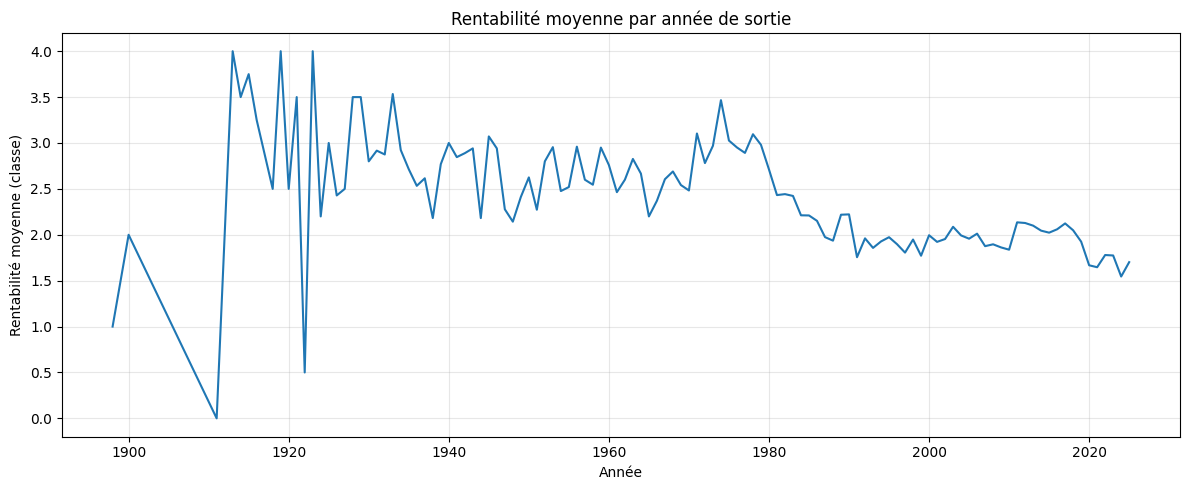

In [13]:
# --- 6.2 Analyse optionnelle : corrélation mois/année et rentabilité ---
# Note : release_month n'a pas été extrait dans le nettoyage.
# On travaille avec release_year uniquement.
# Si tu veux ajouter le mois, il faudrait revenir au CSV brut pour l'extraire.

plt.figure(figsize=(12, 5))
df.groupby('release_year')['rentabilite'].mean().plot()
plt.title('Rentabilité moyenne par année de sortie')
plt.xlabel('Année')
plt.ylabel('Rentabilité moyenne (classe)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/rentabilite_par_annee.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Assemblage final de X et y

On combine toutes les features transformées en une seule matrice X.

**Récapitulatif des features :**
- TF-IDF (150 colonnes) : signal textuel
- Genres one-hot (~20 colonnes) : catégorie du film
- adult_encoded (1 colonne) : film adulte ou non
- is_english (1 colonne) : langue
- budget_scaled (1 colonne) : budget standardisé
- runtime_scaled (1 colonne) : durée standardisée
- release_year (1 colonne) : année de sortie

In [14]:
# --- 7.1 Assemblage ---

# Variables scalaires
scalars_df = df[['adult_encoded', 'is_english', 'release_year']].copy()
scalars_df.index = df.index

# Combiner tout
X = pd.concat([
    tfidf_df,           # TF-IDF (150 cols)
    genres_df,           # Genres one-hot
    num_df,              # budget_scaled, runtime_scaled
    scalars_df           # adult_encoded, is_english, release_year
], axis=1)

# Target
y = df['rentabilite'].copy()

print(f"=== MATRICE FINALE ===")
print(f"X shape : {X.shape} ({X.shape[0]} films, {X.shape[1]} features)")
print(f"y shape : {y.shape}")
print(f"\nNaN dans X : {X.isnull().sum().sum()}")
print(f"NaN dans y : {y.isnull().sum()}")

=== MATRICE FINALE ===
X shape : (16312, 325) (16312 films, 325 features)
y shape : (16312,)

NaN dans X : 0
NaN dans y : 0


In [15]:
# --- 7.2 Vérification : aucune variable interdite ---
colonnes_interdites = ['revenue', 'profit', 'ROI', 'is_profitable', 
                        'vote_average', 'vote_count', 'popularity']

print("Vérification des colonnes interdites dans X :")
for col in colonnes_interdites:
    present = any(col in c for c in X.columns)
    status = '❌ PRÉSENTE — ERREUR !' if present else '✅ Absente'
    print(f"  {col} : {status}")

print(f"\n✅ Aucune fuite d'information (data leakage) détectée." 
      if not any(any(c in col for col in X.columns) for c in colonnes_interdites)
      else "\n❌ ATTENTION : fuite d'information détectée !")

Vérification des colonnes interdites dans X :
  revenue : ✅ Absente
  profit : ✅ Absente
  ROI : ✅ Absente
  is_profitable : ✅ Absente
  vote_average : ✅ Absente
  vote_count : ✅ Absente
  popularity : ✅ Absente

✅ Aucune fuite d'information (data leakage) détectée.


In [16]:
# --- 7.3 Récapitulatif des features par catégorie ---
tfidf_cols = [c for c in X.columns if c.startswith('tfidf_')]
genre_cols = [c for c in X.columns if c.startswith('genre_')]
other_cols = [c for c in X.columns if not c.startswith('tfidf_') and not c.startswith('genre_')]

print(f"=== RÉCAPITULATIF DES FEATURES ===")
print(f"TF-IDF (texte)          : {len(tfidf_cols)} features")
print(f"Genres (one-hot)        : {len(genre_cols)} features")
print(f"Autres (num+cat+temp)   : {len(other_cols)} features")
print(f"  → {other_cols}")
print(f"\nTOTAL                   : {X.shape[1]} features")
print(f"\nDistribution y :")
print(y.value_counts().sort_index())

=== RÉCAPITULATIF DES FEATURES ===
TF-IDF (texte)          : 300 features
Genres (one-hot)        : 20 features
Autres (num+cat+temp)   : 5 features
  → ['budget_scaled', 'runtime_scaled', 'adult_encoded', 'is_english', 'release_year']

TOTAL                   : 325 features

Distribution y :
rentabilite
0    3258
1    3524
2    3103
3    3165
4    3262
Name: count, dtype: int64


## 8. Sauvegarde

In [17]:
# --- 8.1 Sauvegarder X et y en fichiers numpy ---
np.save('../data/processed/X_features.npy', X.values)
np.save('../data/processed/y_target.npy', y.values)

# Sauvegarder aussi les noms des colonnes (utile pour feature importance)
pd.Series(X.columns.tolist()).to_csv('../data/processed/feature_names.csv', index=False)

# Sauvegarder le vectorizer TF-IDF (pour réutilisation)
import joblib
joblib.dump(tfidf, '../data/processed/tfidf_vectorizer.joblib')
joblib.dump(scaler, '../data/processed/standard_scaler.joblib')
joblib.dump(mlb, '../data/processed/genre_encoder.joblib')

print("✅ Fichiers sauvegardés :")
print("  → X_features.npy")
print("  → y_target.npy")
print("  → feature_names.csv")
print("  → tfidf_vectorizer.joblib")
print("  → standard_scaler.joblib")
print("  → genre_encoder.joblib")

✅ Fichiers sauvegardés :
  → X_features.npy
  → y_target.npy
  → feature_names.csv
  → tfidf_vectorizer.joblib
  → standard_scaler.joblib
  → genre_encoder.joblib


In [18]:
# --- 8.2 Tableau récapitulatif pour le rapport ---
recap = pd.DataFrame({
    'Catégorie': ['Texte (TF-IDF)', 'Genres (One-Hot)', 'Budget (standardisé)', 
                  'Runtime (standardisé)', 'Adult (binaire)', 'Langue (is_english)',
                  'Année de sortie'],
    'Source': ['title + keywords + overview', 'genres', 'budget', 
              'runtime', 'adult', 'original_language', 'release_year'],
    'Méthode': ['TF-IDF (max_features=150, min_df=5)', 'MultiLabelBinarizer',
                'StandardScaler', 'StandardScaler', 'Conversion bool→int',
                'Indicateur binaire (en=1)', 'Conservée telle quelle'],
    'Nb features': [len(tfidf_cols), len(genre_cols), 1, 1, 1, 1, 1]
})

print("=== TABLEAU RÉCAPITULATIF FEATURE ENGINEERING ===")
print(recap.to_string(index=False))
print(f"\nTotal features : {X.shape[1]}")
print(f"Total films    : {X.shape[0]}")

=== TABLEAU RÉCAPITULATIF FEATURE ENGINEERING ===
            Catégorie                      Source                             Méthode  Nb features
       Texte (TF-IDF) title + keywords + overview TF-IDF (max_features=150, min_df=5)          300
     Genres (One-Hot)                      genres                 MultiLabelBinarizer           20
 Budget (standardisé)                      budget                      StandardScaler            1
Runtime (standardisé)                     runtime                      StandardScaler            1
      Adult (binaire)                       adult                 Conversion bool→int            1
  Langue (is_english)           original_language           Indicateur binaire (en=1)            1
      Année de sortie                release_year              Conservée telle quelle            1

Total features : 325
Total films    : 16312


---
## ✅ Résumé

Le feature engineering est terminé. Les données sont prêtes pour l'étape suivante :

**→ Notebook 06 : Train/Test Split + PCA + Random Forest**

| Élément | Valeur |
|---------|--------|
| Nombre de films | voir ci-dessus |
| Nombre total de features | voir ci-dessus |
| Variables texte | TF-IDF (150 mots) |
| Variables catégorielles | Genres (one-hot) + adult + is_english |
| Variables numériques | budget + runtime (standardisés) |
| Variables temporelles | release_year |
| Target | rentabilite (5 classes : 0-4) |
| Data leakage | ✅ Aucun |